In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install MONAI and other libraries if not already present
!pip install -q monai segmentation-models-pytorch albumentations

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 17.0 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import cv2
import random
import copy
import matplotlib.pyplot as plt
from tqdm import tqdm

from monai.losses import DiceFocalLoss
from monai.metrics import DiceMetric, MeanIoU
from monai.transforms import (
    Compose, RandRotated, RandFlipd, RandZoomd, RandAffined,
    RandGaussianNoised, RandAdjustContrastd, ToTensord
)
import segmentation_models_pytorch as smp

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
CT_DIR = '/content/drive/MyDrive/Minor-Project under DevraniMam/Faderated_Learning_Based_Lung_Nodule_Detection/LUNA16_segmentation_data/ct'
MASK_DIR = '/content/drive/MyDrive/Minor-Project under DevraniMam/Faderated_Learning_Based_Lung_Nodule_Detection/LUNA16_segmentation_data/mask'

ct_files = sorted([f for f in os.listdir(CT_DIR) if f.endswith('.png')])
mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.endswith('.png')])

assert len(ct_files) == len(mask_files), "CT and mask counts mismatch!"
print(f"Total images: {len(ct_files)}")

ct_paths = [os.path.join(CT_DIR, f) for f in ct_files]
mask_paths = [os.path.join(MASK_DIR, f) for f in mask_files]

Total images: 523


In [ ]:
class LungNoduleDataset(Dataset):
    def __init__(self, ct_paths, mask_paths, transform=None):
        self.ct_paths = ct_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.ct_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.ct_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        img = img.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)

        img = np.expand_dims(img, axis=0)
        mask = np.expand_dims(mask, axis=0)

        data = {'image': img, 'mask': mask}
        if self.transform:
            data = self.transform(data)
        return data['image'], data['mask']

train_transforms = Compose([
    RandRotated(keys=['image','mask'], range_x=0.3, prob=0.5, mode=['bilinear','nearest']),
    RandFlipd(keys=['image','mask'], spatial_axis=0, prob=0.5),
    RandFlipd(keys=['image','mask'], spatial_axis=1, prob=0.5),
    RandZoomd(keys=['image','mask'], min_zoom=0.8, max_zoom=1.2, prob=0.5, mode=['bilinear','nearest']),
    RandAffined(keys=['image','mask'], rotate_range=0.2, translate_range=0.1, scale_range=0.1, prob=0.5, mode=['bilinear','nearest']),
    RandGaussianNoised(keys=['image'], std=0.01, prob=0.3),
    RandAdjustContrastd(keys=['image'], gamma=(0.8,1.2), prob=0.3),
    ToTensord(keys=['image','mask'], dtype=torch.float32),
])

val_transforms = Compose([
    ToTensord(keys=['image','mask'], dtype=torch.float32),
])

In [ ]:
def split_clients(ct_paths, mask_paths, num_clients=5, val_ratio=0.15, test_ratio=0.15):
    indices = np.arange(len(ct_paths))
    np.random.shuffle(indices)
    client_indices = np.array_split(indices, num_clients)

    clients = []
    for client_idx in client_indices:
        train_idx, temp_idx = train_test_split(client_idx, test_size=(val_ratio+test_ratio), random_state=42)
        val_idx, test_idx = train_test_split(temp_idx, test_size=test_ratio/(val_ratio+test_ratio), random_state=42)
        clients.append({
            'train': train_idx.tolist(),
            'val': val_idx.tolist(),
            'test': test_idx.tolist()
        })
    return clients

clients = split_clients(ct_paths, mask_paths, num_clients=5)
print("Client data sizes:")
for i, c in enumerate(clients):
    print(f"Client {i}: train={len(c['train'])}, val={len(c['val'])}, test={len(c['test'])}")

Client data sizes:
Client 0: train=73, val=16, test=16
Client 1: train=73, val=16, test=16
Client 2: train=73, val=16, test=16
Client 3: train=72, val=16, test=16
Client 4: train=72, val=16, test=16


In [ ]:
batch_size = 8
num_workers = 2

client_dataloaders = []
for client in clients:
    train_ds = LungNoduleDataset([ct_paths[i] for i in client['train']],
                                 [mask_paths[i] for i in client['train']],
                                 transform=train_transforms)
    val_ds = LungNoduleDataset([ct_paths[i] for i in client['val']],
                               [mask_paths[i] for i in client['val']],
                               transform=val_transforms)
    test_ds = LungNoduleDataset([ct_paths[i] for i in client['test']],
                                [mask_paths[i] for i in client['test']],
                                transform=val_transforms)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    client_dataloaders.append({
        'train': train_loader,
        'val': val_loader,
        'test': test_loader
    })

In [ ]:
def build_model():
    model = smp.UnetPlusPlus(
        encoder_name="efficientnet-b3",
        encoder_weights="imagenet",
        in_channels=1,
        classes=1,
    )
    return model

model = build_model().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
model.summary()   // new add

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 49.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Model parameters: 13.62M


In [ ]:
loss_fn = DiceFocalLoss(sigmoid=True, squared_pred=True, reduction='mean')
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

def compute_dice(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

def compute_iou(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

In [ ]:
def client_update(global_weights, train_loader, local_epochs=2, lr=1e-4, verbose=True):
    model = build_model().to(device)
    model.load_state_dict(global_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    model.train()
    epoch_losses = []
    epoch_dices = []

    for epoch in range(local_epochs):
        running_loss = 0.0
        running_dice = 0.0
        num_batches = 0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = loss_fn(logits, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            dice = compute_dice(logits.detach(), masks)
            running_loss += loss.item()
            running_dice += dice.item()
            num_batches += 1

        avg_loss = running_loss / num_batches
        avg_dice = running_dice / num_batches
        epoch_losses.append(avg_loss)
        epoch_dices.append(avg_dice)

        if verbose:
            print(f"    Local Epoch {epoch+1}/{local_epochs} - Loss: {avg_loss:.4f}, Dice: {avg_dice:.4f}")

    return model.state_dict(), len(train_loader.dataset), epoch_losses, epoch_dices

def aggregate_weights(client_weights, total_samples):
    new_weights = {}
    for key in client_weights[0][0].keys():
        weighted_sum = torch.zeros_like(client_weights[0][0][key])
        for w, n in client_weights:
            weighted_sum += w[key] * n
        new_weights[key] = weighted_sum / total_samples
    return new_weights

def evaluate(weights, dataloader):
    model = build_model().to(device)
    model.load_state_dict(weights)
    model.eval()
    dice_scores = []
    iou_scores = []
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            dice = compute_dice(logits, masks)
            iou = compute_iou(logits, masks)
            dice_scores.append(dice.item())
            iou_scores.append(iou.item())
    return np.mean(dice_scores), np.mean(iou_scores)

In [ ]:
global_weights = build_model().state_dict()

num_rounds = 50
local_epochs = 2
local_lr = 1e-4

results = {'round': [], 'avg_val_dice': [], 'avg_test_dice': [], 'avg_test_iou': []}

for round in range(num_rounds):
    print(f"--- Federated Round {round+1}/{num_rounds} ---")
    client_weights = []
    total_samples = 0

    for i, client in enumerate(client_dataloaders):
        print(f"  Client {i} training...")
        w, n, _, _ = client_update(global_weights, client['train'],
                                   local_epochs=local_epochs, lr=local_lr, verbose=True)
        client_weights.append((w, n))
        total_samples += n

    global_weights = aggregate_weights(client_weights, total_samples)

    if (round+1) % 5 == 0 or round == num_rounds-1:
        val_dices = []
        test_dices = []
        test_ious = []
        for i, client in enumerate(client_dataloaders):
            val_dice, _ = evaluate(global_weights, client['val'])
            test_dice, test_iou = evaluate(global_weights, client['test'])
            val_dices.append(val_dice)
            test_dices.append(test_dice)
            test_ious.append(test_iou)
        avg_val_dice = np.mean(val_dices)
        avg_test_dice = np.mean(test_dices)
        avg_test_iou = np.mean(test_ious)
        results['round'].append(round+1)
        results['avg_val_dice'].append(avg_val_dice)
        results['avg_test_dice'].append(avg_test_dice)
        results['avg_test_iou'].append(avg_test_iou)
        print(f"  Round {round+1}: Avg Val Dice={avg_val_dice:.4f}, Avg Test Dice={avg_test_dice:.4f}, Avg Test IoU={avg_test_iou:.4f}")

--- Federated Round 1/50 ---
  Client 0 training...
    Local Epoch 1/2 - Loss: 1.5344, Dice: 0.0019
    Local Epoch 2/2 - Loss: 1.4183, Dice: 0.0015
  Client 1 training...
    Local Epoch 1/2 - Loss: 1.5342, Dice: 0.0019
    Local Epoch 2/2 - Loss: 1.4191, Dice: 0.0018
  Client 2 training...
    Local Epoch 1/2 - Loss: 1.5369, Dice: 0.0019
    Local Epoch 2/2 - Loss: 1.4211, Dice: 0.0016
  Client 3 training...
    Local Epoch 1/2 - Loss: 1.5400, Dice: 0.0019
    Local Epoch 2/2 - Loss: 1.4285, Dice: 0.0017
  Client 4 training...
    Local Epoch 1/2 - Loss: 1.5405, Dice: 0.0021
    Local Epoch 2/2 - Loss: 1.4313, Dice: 0.0018
--- Federated Round 2/50 ---
  Client 0 training...
    Local Epoch 1/2 - Loss: 1.3305, Dice: 0.0016
    Local Epoch 2/2 - Loss: 1.2426, Dice: 0.0017
  Client 1 training...
    Local Epoch 1/2 - Loss: 1.3230, Dice: 0.0023
    Local Epoch 2/2 - Loss: 1.2430, Dice: 0.0017
  Client 2 training...
    Local Epoch 1/2 - Loss: 1.3282, Dice: 0.0016
    Local Epoch 2/2 - L

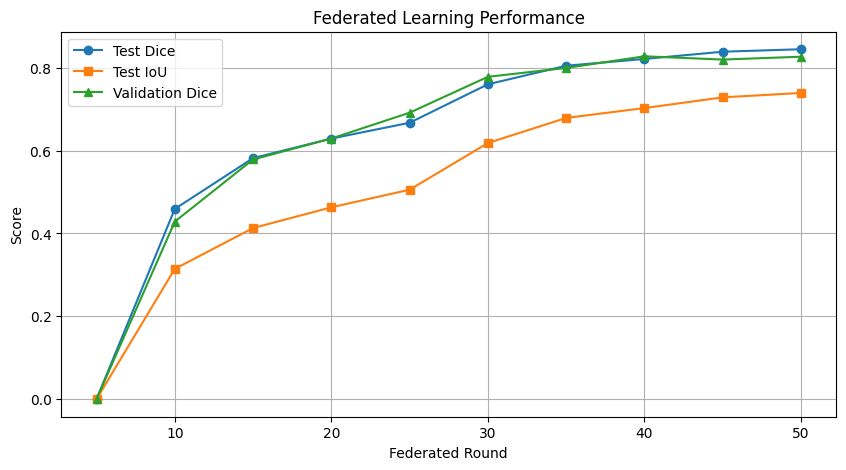

Model saved!


In [ ]:
plt.figure(figsize=(10,5))
plt.plot(results['round'], results['avg_test_dice'], label='Test Dice', marker='o')
plt.plot(results['round'], results['avg_test_iou'], label='Test IoU', marker='s')
plt.plot(results['round'], results['avg_val_dice'], label='Validation Dice', marker='^')
plt.xlabel('Federated Round')
plt.ylabel('Score')
plt.legend()
plt.title('Federated Learning Performance')
plt.grid(True)
plt.show()

torch.save(global_weights, '/content/drive/MyDrive/federated_lung_nodule_unetpp_effb3.pth')
print("Model saved!")

In [ ]:
# ---------- New evaluation functions ----------
def compute_dice_from_probs(probs, target, threshold=0.5):
    preds = (probs > threshold).float()
    intersection = (preds * target).sum()
    return (2. * intersection + 1e-6) / (preds.sum() + target.sum() + 1e-6)

def compute_iou_from_probs(probs, target, threshold=0.5):
    preds = (probs > threshold).float()
    intersection = (preds * target).sum()
    union = preds.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def postprocess_mask_light(mask, min_area=2, fill_holes=True):
    """Remove only tiny components (area < min_area) and fill holes."""
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
    mask = mask.astype(np.uint8)
    # Remove small connected components
    num_labels, labels = cv2.connectedComponents(mask)
    cleaned = np.zeros_like(mask)
    for lab in range(1, num_labels):
        component = (labels == lab).astype(np.uint8)
        if np.sum(component) >= min_area:
            cleaned = np.logical_or(cleaned, component)
    cleaned = cleaned.astype(np.uint8)

    if fill_holes:
        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            cv2.drawContours(cleaned, [cnt], 0, 1, thickness=cv2.FILLED)
    return cleaned

def find_best_threshold(weights, val_loader):
    """Find optimal threshold on validation set."""
    model = build_model().to(device)
    model.load_state_dict(weights)
    model.eval()
    best_dice = 0.0
    best_thresh = 0.5
    thresholds = np.arange(0.3, 0.7, 0.02)
    with torch.no_grad():
        for thresh in thresholds:
            dice_scores = []
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                logits = model(imgs)
                probs = torch.sigmoid(logits)
                dice = compute_dice_from_probs(probs, masks, threshold=thresh)
                dice_scores.append(dice.item())
            avg_dice = np.mean(dice_scores)
            if avg_dice > best_dice:
                best_dice = avg_dice
                best_thresh = thresh
    return best_thresh

def evaluate_with_optimizations(weights, dataloader, threshold=0.5, apply_postprocess=True):
    """Evaluate with threshold and light post-processing."""
    model = build_model().to(device)
    model.load_state_dict(weights)
    model.eval()
    dice_scores = []
    iou_scores = []
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float().cpu().numpy()
            if apply_postprocess:
                preds_pp = np.zeros_like(preds)
                for i in range(preds.shape[0]):
                    preds_pp[i,0] = postprocess_mask_light(preds[i,0], min_area=2, fill_holes=True)
                preds = torch.tensor(preds_pp, device=device).float()
            else:
                preds = torch.tensor(preds, device=device).float()
            dice = compute_dice_from_pred(preds, masks)
            iou = compute_iou_from_pred(preds, masks)
            dice_scores.append(dice.item())
            iou_scores.append(iou.item())
    return np.mean(dice_scores), np.mean(iou_scores)

def compute_dice_from_pred(preds, target):
    intersection = (preds * target).sum()
    return (2. * intersection + 1e-6) / (preds.sum() + target.sum() + 1e-6)

def compute_iou_from_pred(preds, target):
    intersection = (preds * target).sum()
    union = preds.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def evaluate_tta_enhanced(weights, dataloader, threshold=0.5, apply_postprocess=True):
    """TTA with 4 flip combinations + optional post-processing."""
    model = build_model().to(device)
    model.load_state_dict(weights)
    model.eval()
    dice_scores = []
    iou_scores = []

    flips = [(False, False), (True, False), (False, True), (True, True)]  # (hflip, vflip)

    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            probs_sum = torch.zeros_like(imgs, dtype=torch.float32)

            for hflip, vflip in flips:
                aug_imgs = imgs
                if hflip:
                    aug_imgs = torch.flip(aug_imgs, dims=[-1])
                if vflip:
                    aug_imgs = torch.flip(aug_imgs, dims=[-2])

                logits = model(aug_imgs)
                probs = torch.sigmoid(logits)

                if vflip:
                    probs = torch.flip(probs, dims=[-2])
                if hflip:
                    probs = torch.flip(probs, dims=[-1])
                probs_sum += probs

            probs_avg = probs_sum / len(flips)
            preds = (probs_avg > threshold).float().cpu().numpy()
            if apply_postprocess:
                preds_pp = np.zeros_like(preds)
                for i in range(preds.shape[0]):
                    preds_pp[i,0] = postprocess_mask_light(preds[i,0], min_area=2, fill_holes=True)
                preds = torch.tensor(preds_pp, device=device).float()
            else:
                preds = torch.tensor(preds, device=device).float()

            dice = compute_dice_from_pred(preds, masks)
            iou = compute_iou_from_pred(preds, masks)
            dice_scores.append(dice.item())
            iou_scores.append(iou.item())
    return np.mean(dice_scores), np.mean(iou_scores)

In [ ]:
# Find best threshold on validation set (using client 0 as proxy)
best_thresh = find_best_threshold(global_weights, client_dataloaders[0]['val'])
print(f"Best threshold on client 0 validation: {best_thresh:.2f}")

# Evaluate all test clients with optimized settings
test_dices = []
test_ious = []
for i, client in enumerate(client_dataloaders):
    dice, iou = evaluate_with_optimizations(global_weights, client['test'],
                                            threshold=best_thresh, apply_postprocess=True)
    test_dices.append(dice)
    test_ious.append(iou)
    print(f"Client {i}: Dice={dice:.4f}, IoU={iou:.4f}")

avg_dice = np.mean(test_dices)
avg_iou = np.mean(test_ious)
print(f"\nAverage Test Dice = {avg_dice:.4f}, Average Test IoU = {avg_iou:.4f}")

Best threshold on client 0 validation: 0.44
Client 0: Dice=0.8618, IoU=0.7576
Client 1: Dice=0.8800, IoU=0.7864
Client 2: Dice=0.8846, IoU=0.7932
Client 3: Dice=0.7146, IoU=0.5671
Client 4: Dice=0.8976, IoU=0.8149

Average Test Dice = 0.8477, Average Test IoU = 0.7439


In [ ]:
# Evaluate with TTA + optimizations on all test clients
tta_dices = []
tta_ious = []
for i, client in enumerate(client_dataloaders):
    dice, iou = evaluate_tta_enhanced(global_weights, client['test'],
                                      threshold=best_thresh, apply_postprocess=True)
    tta_dices.append(dice)
    tta_ious.append(iou)
    print(f"TTA Client {i}: Dice={dice:.4f}, IoU={iou:.4f}")

avg_tta_dice = np.mean(tta_dices)
avg_tta_iou = np.mean(tta_ious)
print(f"\nAverage TTA Dice = {avg_tta_dice:.4f}, Average TTA IoU = {avg_tta_iou:.4f}")

TTA Client 0: Dice=0.8474, IoU=0.7361
TTA Client 1: Dice=0.8802, IoU=0.7864
TTA Client 2: Dice=0.8943, IoU=0.8091
TTA Client 3: Dice=0.6976, IoU=0.5493
TTA Client 4: Dice=0.8895, IoU=0.8013

Average TTA Dice = 0.8418, Average TTA IoU = 0.7364


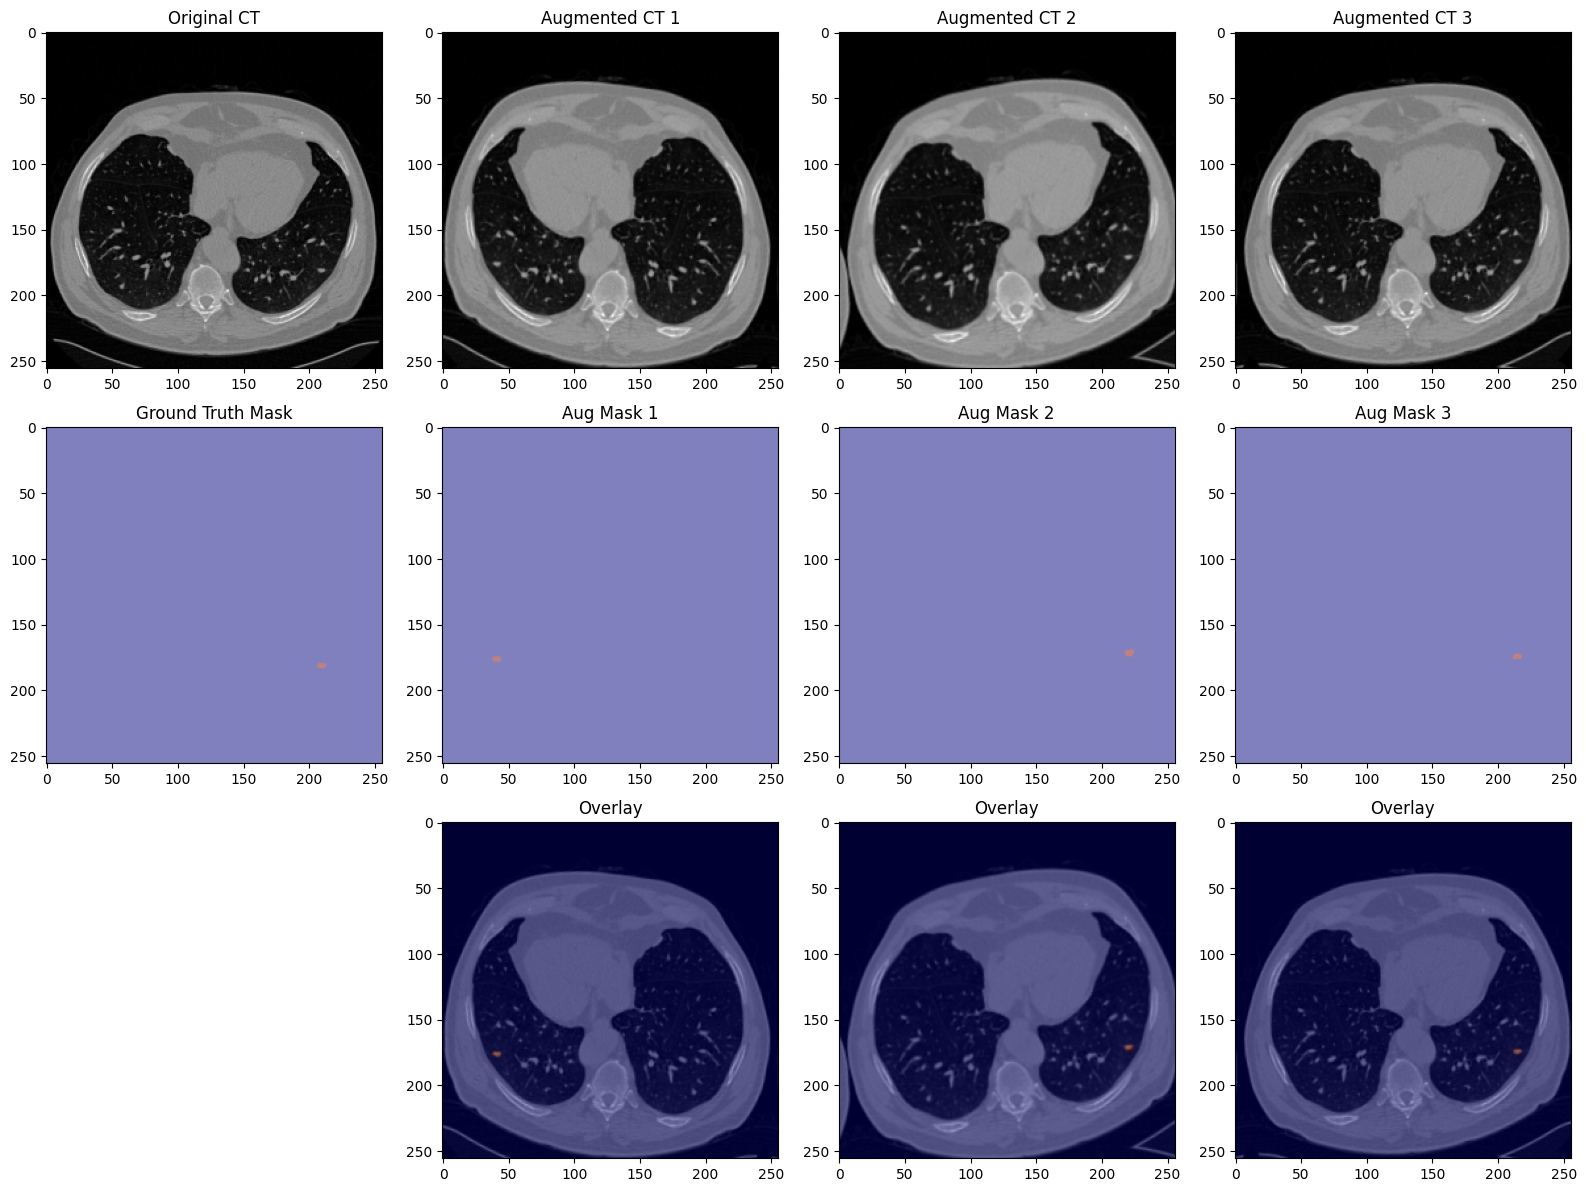

In [ ]:
import matplotlib.pyplot as plt

# Pick a random image
sample_idx = random.randint(0, len(ct_paths)-1)
ct_img = cv2.imread(ct_paths[sample_idx], cv2.IMREAD_GRAYSCALE)
mask_img = cv2.imread(mask_paths[sample_idx], cv2.IMREAD_GRAYSCALE)

ct_resized = cv2.resize(ct_img, (256, 256)) / 255.0
mask_resized = (cv2.resize(mask_img, (256, 256), interpolation=cv2.INTER_NEAREST) > 127).astype(np.float32)

data_dict = {'image': np.expand_dims(ct_resized, 0), 'mask': np.expand_dims(mask_resized, 0)}

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
# Original
axes[0,0].imshow(ct_resized, cmap='gray')
axes[0,0].set_title('Original CT')
axes[1,0].imshow(mask_resized, cmap='jet', alpha=0.5)
axes[1,0].set_title('Ground Truth Mask')
axes[2,0].axis('off')

for i in range(1,4):
    augmented = train_transforms(data_dict.copy())
    aug_img = augmented['image'].squeeze().numpy()
    aug_mask = augmented['mask'].squeeze().numpy()

    axes[0,i].imshow(aug_img, cmap='gray')
    axes[0,i].set_title(f'Augmented CT {i}')
    axes[1,i].imshow(aug_mask, cmap='jet', alpha=0.5)
    axes[1,i].set_title(f'Aug Mask {i}')
    axes[2,i].imshow(aug_img, cmap='gray')
    axes[2,i].imshow(aug_mask, cmap='jet', alpha=0.4)
    axes[2,i].set_title('Overlay')

plt.tight_layout()
plt.show()

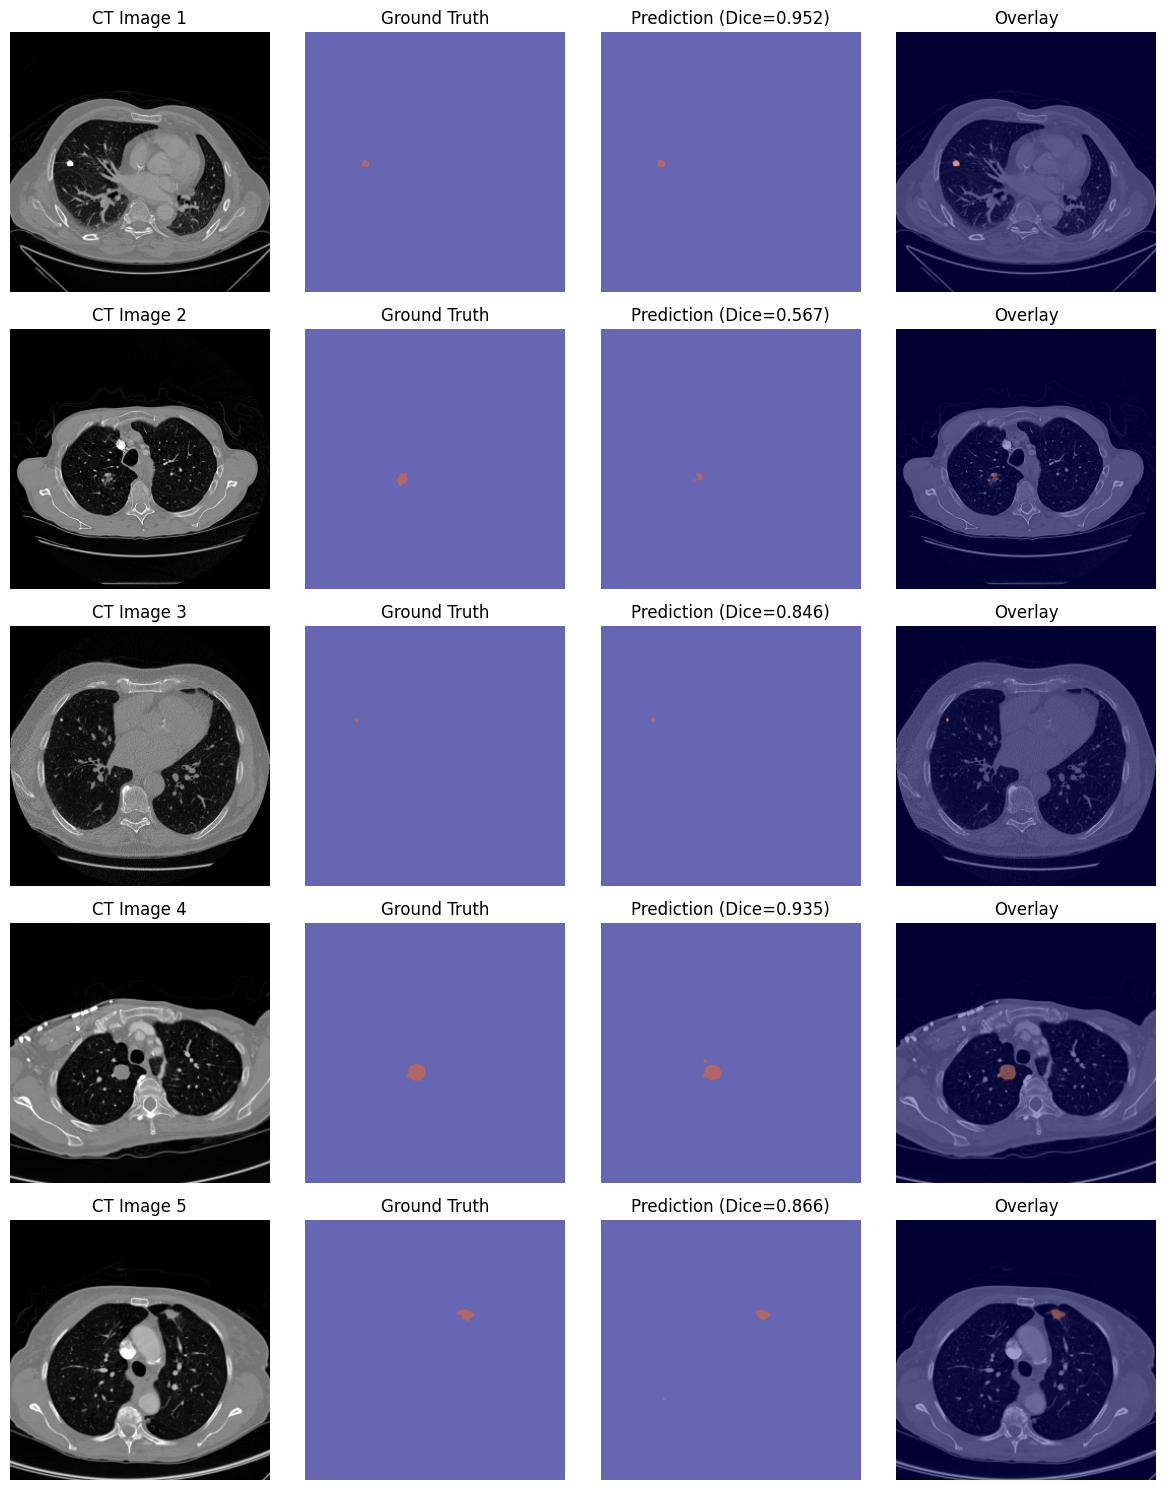

In [ ]:
def visualize_predictions_optimized(weights, dataloader, num_samples=5, threshold=0.5):
    model = build_model().to(device)
    model.load_state_dict(weights)
    model.eval()

    data_iter = iter(dataloader)
    imgs, masks = next(data_iter)
    imgs, masks = imgs.to(device), masks.to(device)

    with torch.no_grad():
        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float().cpu().numpy()
        # Apply light post-processing
        preds_pp = np.zeros_like(preds)
        for i in range(preds.shape[0]):
            preds_pp[i,0] = postprocess_mask_light(preds[i,0], min_area=2, fill_holes=True)
        preds = preds_pp

    imgs_np = imgs.cpu().numpy().squeeze(1)
    masks_np = masks.cpu().numpy().squeeze(1)
    preds_np = preds.squeeze(1)

    fig, axes = plt.subplots(num_samples, 4, figsize=(12, 3*num_samples))
    if num_samples == 1:
        axes = axes[None, :]

    for i in range(num_samples):
        ct = imgs_np[i]
        gt = masks_np[i]
        pred = preds_np[i]

        dice = compute_dice_from_pred(torch.tensor(pred).float().unsqueeze(0).unsqueeze(0),
                                      torch.tensor(gt).float().unsqueeze(0).unsqueeze(0)).item()

        axes[i,0].imshow(ct, cmap='gray')
        axes[i,0].set_title(f'CT Image {i+1}')
        axes[i,0].axis('off')

        axes[i,1].imshow(gt, cmap='jet', alpha=0.6)
        axes[i,1].set_title('Ground Truth')
        axes[i,1].axis('off')

        axes[i,2].imshow(pred, cmap='jet', alpha=0.6)
        axes[i,2].set_title(f'Prediction (Dice={dice:.3f})')
        axes[i,2].axis('off')

        axes[i,3].imshow(ct, cmap='gray')
        axes[i,3].imshow(pred, cmap='jet', alpha=0.4)
        axes[i,3].set_title('Overlay')
        axes[i,3].axis('off')

    plt.tight_layout()
    plt.show()

# Use the best threshold found earlier
visualize_predictions_optimized(global_weights, client_dataloaders[0]['test'], num_samples=5, threshold=best_thresh)

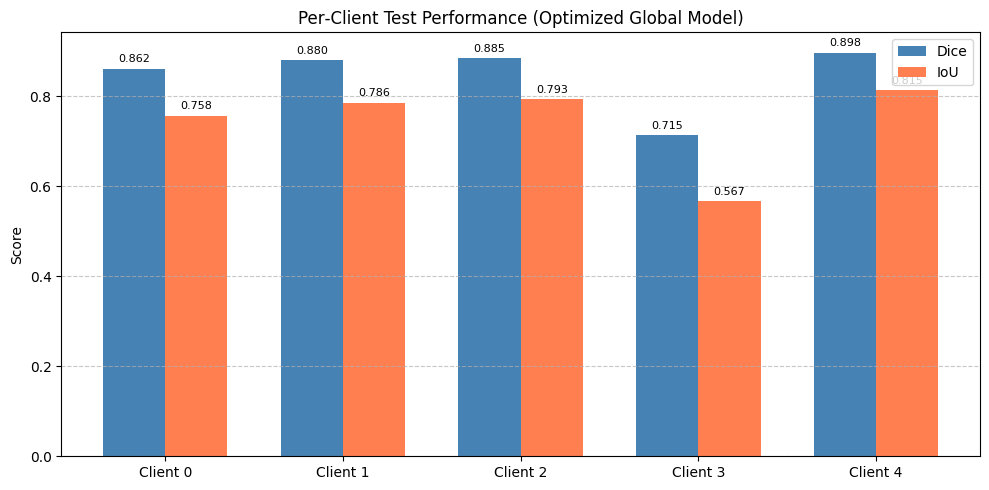

In [ ]:
client_dices = []
client_ious = []
client_names = []

for i, client in enumerate(client_dataloaders):
    # Use optimized evaluation
    dice, iou = evaluate_with_optimizations(global_weights, client['test'],
                                            threshold=best_thresh, apply_postprocess=True)
    client_dices.append(dice)
    client_ious.append(iou)
    client_names.append(f'Client {i}')

x = np.arange(len(client_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
bar1 = ax.bar(x - width/2, client_dices, width, label='Dice', color='steelblue')
bar2 = ax.bar(x + width/2, client_ious, width, label='IoU', color='coral')

ax.set_ylabel('Score')
ax.set_title('Per‑Client Test Performance (Optimized Global Model)')
ax.set_xticks(x)
ax.set_xticklabels(client_names)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bar1+bar2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

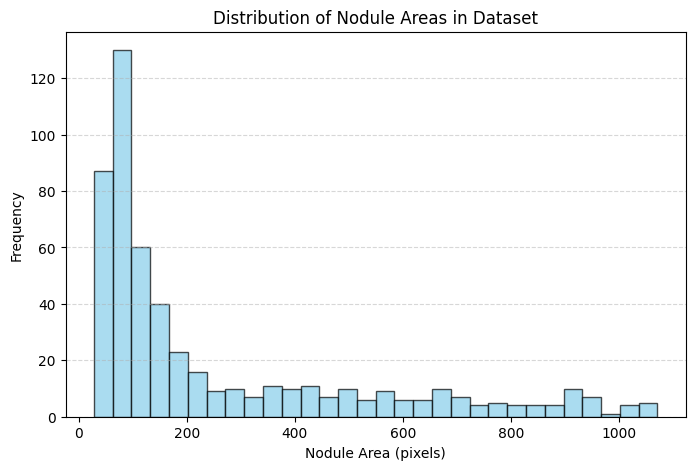

In [ ]:
nodule_areas = []
for mask_path in mask_paths:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.uint8)
    area = np.sum(mask)
    if area > 0:
        nodule_areas.append(area)

plt.figure(figsize=(8,5))
plt.hist(nodule_areas, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Nodule Area (pixels)')
plt.ylabel('Frequency')
plt.title('Distribution of Nodule Areas in Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

<Figure size 600x600 with 0 Axes>

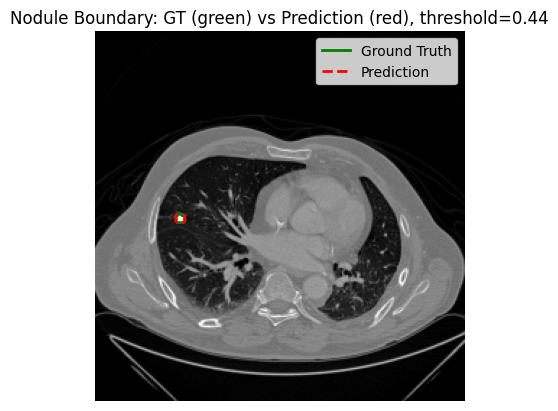

In [ ]:
def overlay_contour(ct_img, pred_mask, gt_mask=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(ct_img, cmap='gray')
    if gt_mask is not None:
        contours, _ = cv2.findContours(gt_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:
            ax.plot(c[:,0,0], c[:,0,1], 'g-', linewidth=2, label='Ground Truth')
    if pred_mask is not None:
        contours, _ = cv2.findContours(pred_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:
            ax.plot(c[:,0,0], c[:,0,1], 'r--', linewidth=2, label='Prediction')
    ax.legend()
    ax.axis('off')

example_idx = clients[0]['test'][0]
ct_ex = cv2.imread(ct_paths[example_idx], cv2.IMREAD_GRAYSCALE)
ct_ex = cv2.resize(ct_ex, (256,256)) / 255.0
gt_ex = (cv2.resize(cv2.imread(mask_paths[example_idx], cv2.IMREAD_GRAYSCALE), (256,256), interpolation=cv2.INTER_NEAREST) > 127).astype(np.float32)

model = build_model().to(device)
model.load_state_dict(global_weights)
model.eval()
with torch.no_grad():
    input_tensor = torch.tensor(ct_ex[None,None,...], dtype=torch.float32).to(device)
    pred_prob = torch.sigmoid(model(input_tensor)).cpu().numpy().squeeze()
pred_mask = (pred_prob > best_thresh).astype(np.float32)
pred_mask = postprocess_mask_light(pred_mask, min_area=2, fill_holes=True)

plt.figure(figsize=(6,6))
overlay_contour(ct_ex, pred_mask, gt_ex)
plt.title(f'Nodule Boundary: GT (green) vs Prediction (red), threshold={best_thresh:.2f}')
plt.show()